# 04 多角形パッキング — NFPを用いたBL法

## 理論まとめ

### 矩形版との違い

| 項目 | 矩形版 | 多角形版 |
|------|--------|----------|
| NFPの計算 | 公式一発（矩形同士は必ず矩形） | pyclipperのMinkowskiDiffを使用 |
| IFRの計算 | バウンディングボックス | 底辺最左点ベース |
| 候補点 | 既配置矩形のコーナー | IFR頂点・NFP頂点・辺の交点（IFR×NFP、NFP×NFP） |
| 回転 | なし | 離散的（0, 90, 180, 270度） |
| キャッシュ | なし | 全ペアのNFP・IFRを事前計算 |

### 実装上のポイント

**MinkowskiDiffの自己交差問題**
pyclipperのMinkowskiDiffは自己交差したポリゴンを返すことがある。
`buffer(0)`で修正することで正しいポリゴンが得られる。

**候補点にNFP同士の交点が必要な理由**
複数の既配置図形がある場合、あるNFPの辺と別のNFPの辺の交点が
「ちょうどどちらのNFPの外部でもある」BL点になりえる。
IFR×NFPの交点だけでは不十分。

In [1]:
import sys
sys.path.insert(0, '..')

from algorithms.nfp_polygon import (
    make_polygon, rotate_polygon,
    calc_nfp_polygon, calc_ifr_polygon,
    build_nfp_cache, build_ifr_cache,
)
from algorithms.polygon_bl import bl_method_polygon
from utils.visualizer import plot_polygon_packing
import matplotlib.pyplot as plt
import time

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


## 1. NFP・IFRの計算確認

In [2]:
# 矩形同士でNFPを確認（矩形版と同じ結果になるはず）
rect_a = make_polygon([(0,0),(10,0),(10,5),(0,5)])
rect_b = make_polygon([(0,0),(6,0),(6,4),(0,4)])

nfp = calc_nfp_polygon(rect_a, rect_b)
ifr = calc_ifr_polygon(bin_w=30, bin_h_max=1000, poly=rect_b)

print(f'NFP(A,B): bounds={nfp.bounds}')
print(f'期待値: x=[-6,10] y=[-4,5]')
print()
print(f'IFR: bounds={ifr.bounds}')
print(f'期待値: x=[0,24] y=[0,996]')

# L字型でNFPを確認
l_shape = make_polygon([(0,0),(20,0),(20,10),(10,10),(10,20),(0,20)])
nfp_l = calc_nfp_polygon(l_shape, rect_b)
print()
print(f'NFP(L字型, 矩形B): is_valid={nfp_l.is_valid}  area={nfp_l.area:.1f}')

NFP(A,B): bounds=(-6.0, -4.0, 10.0, 5.0)
期待値: x=[-6,10] y=[-4,5]

IFR: bounds=(0.0, 0.0, 24.0, 996.0)
期待値: x=[0,24] y=[0,996]

NFP(L字型, 矩形B): is_valid=True  area=524.0


## 2. end0tknrさんの例題で動作確認

実行時間: 0.387s

図形0: 参照点=(66.7, 0.0)  回転角=90度
図形1: 参照点=(0.0, 0.0)  回転角=0度
図形2: 参照点=(80.0, 20.0)  回転角=0度
図形3: 参照点=(101.7, 0.0)  回転角=90度
図形4: 参照点=(40.0, 0.0)  回転角=0度


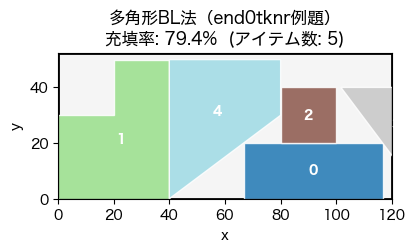

<Axes: title={'center': '多角形BL法（end0tknr例題）\n充填率: 79.4%  (アイテム数: 5)'}, xlabel='x', ylabel='y'>

In [3]:
# 参考: https://end0tknr.hateblo.jp/entry/20221122/1669057478
vertices_list = [
    [(0,0),(20,0),(20,50),(0,50)],
    [(0,0),(40,0),(40,50),(20,50),(20,30),(0,30)],
    [(0,0),(20,0),(20,20),(0,20)],
    [(0,0),(40,0),(40,30)],
    [(0,0),(40,30),(40,50),(0,50)],
]
bin_w = 120

t0 = time.perf_counter()
positions, thetas, placed_polys = bl_method_polygon(
    vertices_list, bin_w,
    orientations=[0, 90, 180, 270],
    sort_key='area'
)
elapsed = time.perf_counter() - t0

print(f'実行時間: {elapsed:.3f}s')
print()
for i, (pos, theta) in enumerate(zip(positions, thetas)):
    print(f'図形{i}: 参照点=({pos[0]:.1f}, {pos[1]:.1f})  回転角={theta}度')

plot_polygon_packing(
    placed_polys, positions, bin_w,
    title='多角形BL法（end0tknr例題）'
)

## 3. 回転なしと回転ありの比較

In [8]:
# 縦横比が極端な図形を混ぜる
vertices_list_rot = [
    [(0,0),(40,0),(40,10),(0,10)],   # 横長矩形（回転すると縦長になる）
    [(0,0),(5,0),(5,30),(0,30)],     # 縦長矩形
    [(0,0),(30,0),(30,5),(0,5)],     # 横長矩形
    [(0,0),(20,0),(20,15),(0,15)],   # やや横長
    [(0,0),(8,0),(8,25),(0,25)],     # 縦長矩形
]
bin_w_rot = 50  # やや狭いビン幅

def fill_rate_polygon(polygons, positions, bin_w):
    used_h = max(pos[1] + poly.bounds[3] for poly, pos in zip(polygons, positions))
    return sum(p.area for p in polygons) / ((bin_w * used_h) * 1.05) * 100

results = []
for orientations, label in [
    ([0],             '回転なし（0度のみ）'),
    ([0, 180],        '回転あり（0/180度）'),
    ([0, 90, 180, 270], '回転あり（0/90/180/270度）'),
]:
    t0 = time.perf_counter()
    pos, thetas, polys = bl_method_polygon(
        vertices_list_rot, bin_w_rot,
        orientations=orientations, sort_key='area'
    )
    elapsed = time.perf_counter() - t0
    fill = fill_rate_polygon(polys, pos, bin_w_rot)
    print(f'{label:25s}: 充填率={fill:.1f}%  時間={elapsed:.3f}s')
    results.append({'label': label, 'polys': polys, 'positions': pos, 'fill': fill})

回転なし（0度のみ）               : 充填率=50.8%  時間=0.048s
回転あり（0/180度）             : 充填率=50.8%  時間=0.052s
回転あり（0/90/180/270度）      : 充填率=57.1%  時間=0.235s


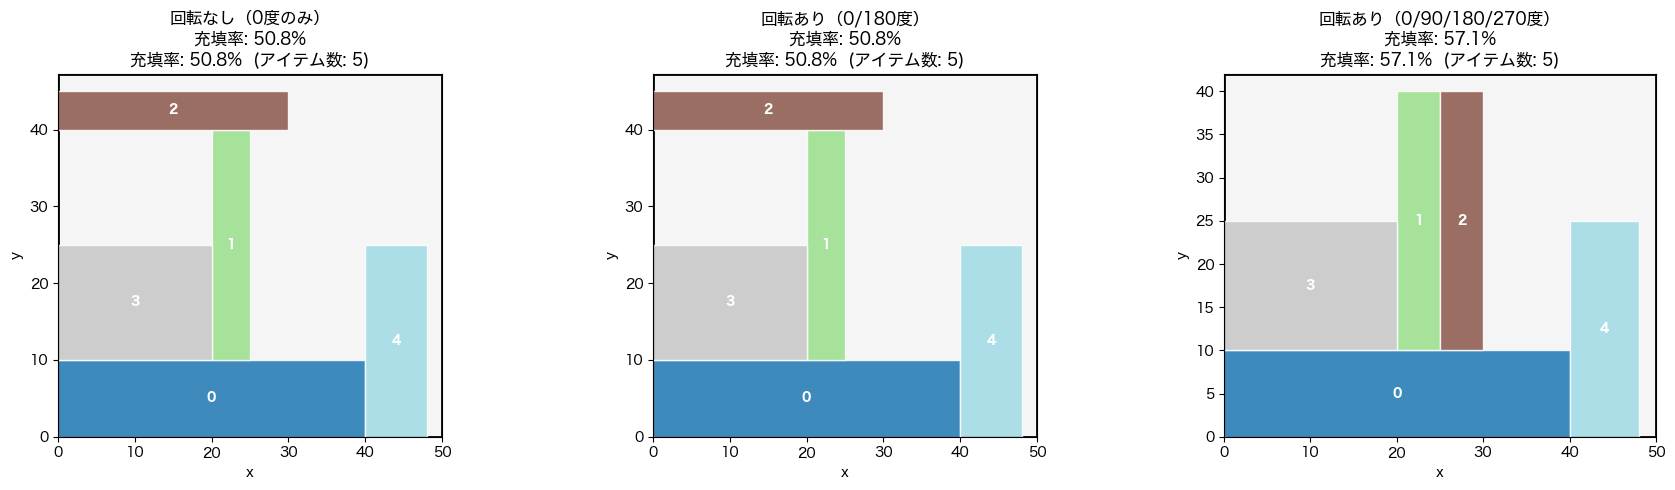

In [9]:
# 横並びで比較
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
from utils.visualizer import plot_polygon_packing

for ax, r in zip(axes, results):
    plot_polygon_packing(
        r['polys'], r['positions'], bin_w_rot,
        title=f"{r['label']}\n充填率: {r['fill']:.1f}%",
        ax=ax, show=False
    )

plt.tight_layout()
plt.show()

## 4. L字型・T字型など非凸図形のテスト

充填率: 79.4%  実行時間: 0.219s


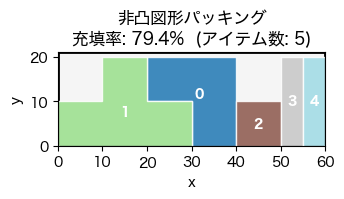

<Axes: title={'center': '非凸図形パッキング\n充填率: 79.4%  (アイテム数: 5)'}, xlabel='x', ylabel='y'>

In [7]:
# 非凸図形を含む問題
vertices_nonconvex = [
    [(0,0),(20,0),(20,10),(10,10),(10,20),(0,20)],   # L字型
    [(0,0),(30,0),(30,10),(20,10),(20,20),(10,20),(10,10),(0,10)],  # U字型
    [(0,0),(10,0),(10,10),(0,10)],                   # 正方形
    [(0,0),(20,0),(20,5),(0,5)],                     # 横長矩形
    [(0,0),(5,0),(5,20),(0,20)],                     # 縦長矩形
]
bin_w_nc = 60

t0 = time.perf_counter()
pos_nc, thetas_nc, polys_nc = bl_method_polygon(
    vertices_nonconvex, bin_w_nc,
    orientations=[0, 90, 180, 270], sort_key='area'
)
elapsed_nc = time.perf_counter() - t0

fill_nc = fill_rate_polygon(polys_nc, pos_nc, bin_w_nc)
print(f'充填率: {fill_nc:.1f}%  実行時間: {elapsed_nc:.3f}s')

plot_polygon_packing(
    polys_nc, pos_nc, bin_w_nc,
    title='非凸図形パッキング'
)

## まとめ・次のステップ

- 多角形NFPの計算（MinkowskiDiff + buffer(0)修正）が正しく動作することを確認した
- 凸・非凸多角形の両方に対応したBL法が実装できた
- 回転角を増やすことで充填率が改善されることを確認した

**実装で詰まったポイント:**
- MinkowskiDiffが自己交差ポリゴンを返すことがある → `buffer(0)`で修正
- 候補点にNFP同士の辺の交点が必要 → IFR×NFPだけでは不十分

**次: Phase 5c — Streamlitデモへの統合・README更新**
- 多角形パッキングをStreamlitデモに追加
- Qiita記事（3本目）の執筆